### Load the dataset and Clean the data

#### import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### a. Import the dataset

df = pd.read_csv(r"D:\Shrabani.Personal\Self Project\Logistic Regression Practice\dataset.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [2]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [3]:
df.shape

(303, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
df.duplicated().sum()

1

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.duplicated().sum()

0

In [9]:
#### b. Get information about the dataset (mean, max, min, quartiles etc.)

df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
### c. Find the correlation between all fields

x=df.corr()
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


### 2. Data Visualization:

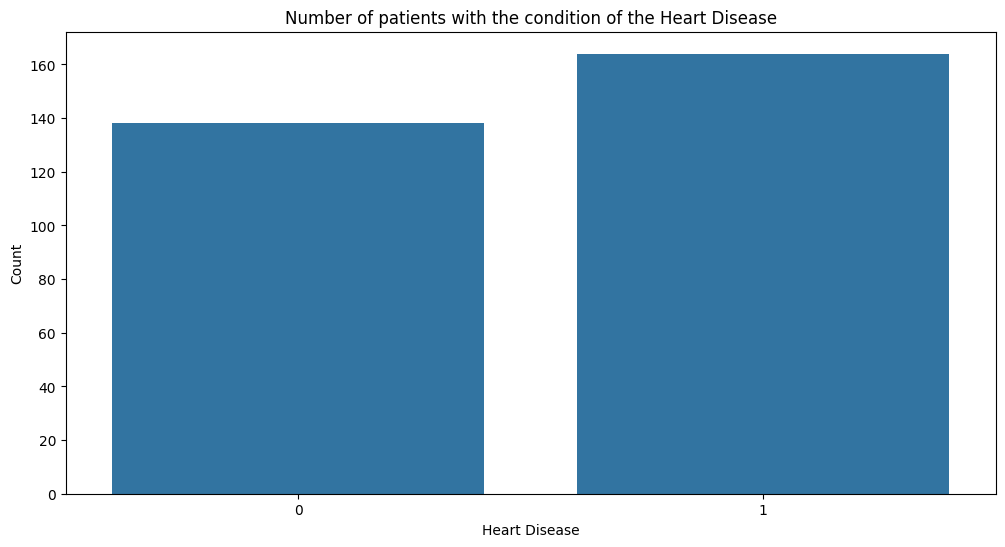

In [11]:
### a. Visualize the number of patients having a heart disease and not having a heart disease

plt.figure (figsize=(12,6))
sns.countplot( data =df, x='target')
plt.title("Number of patients with the condition of the Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

In [12]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

#### From this plot it is clear that in this dataset 164 people have the heart disease and 138 people do not have heart disease.

### b. Visualize the age and whether a patient has disease or not

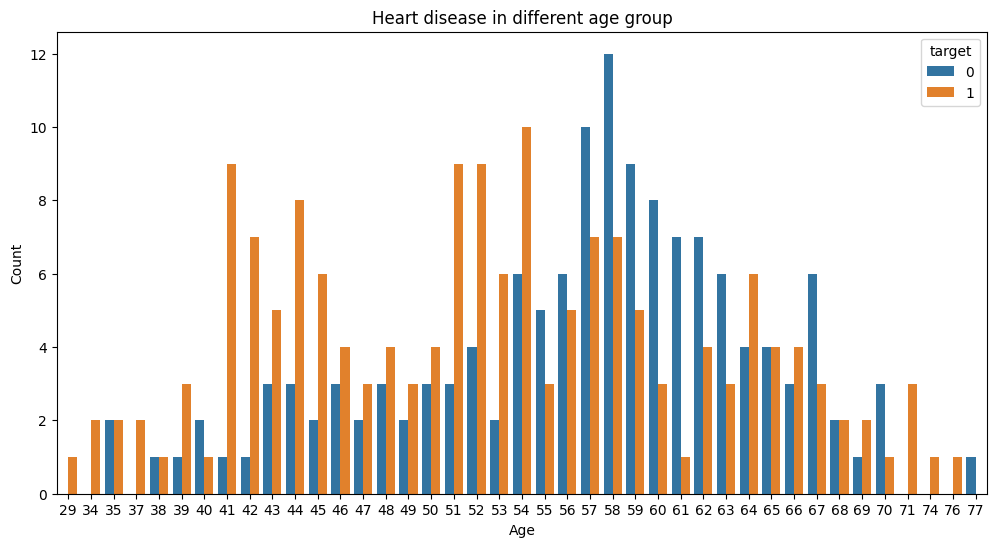

In [13]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="age", hue="target")
plt.title("Heart disease in different age group")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

#### From this figure it is clear that for the middle aged persons have more heart disease.

### c. Visualize correlation between all features using a heat map

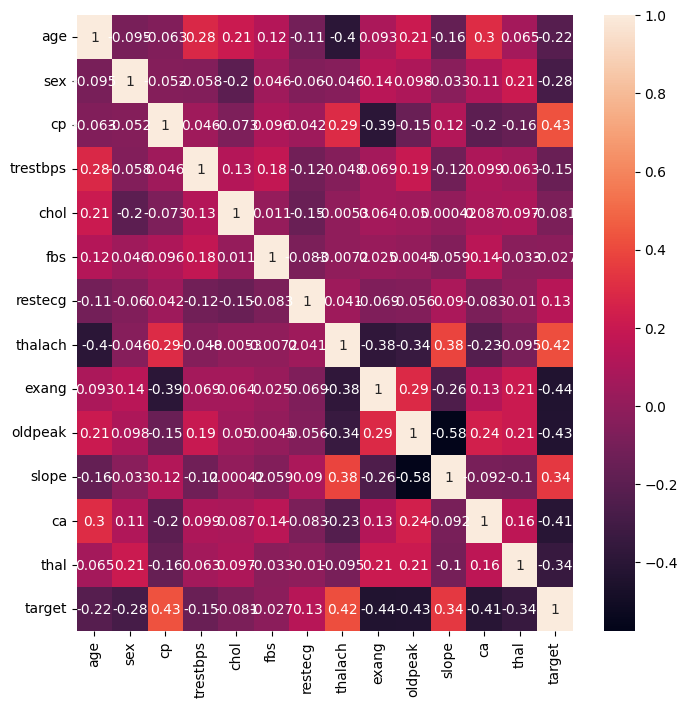

In [14]:
plt.figure(figsize=(8,8))
sns.heatmap(x, annot=True)
plt.show()

### 3. Logistic Regression:
### a. Build a simple logistic regression model:
### i. Divide the dataset in 70:30 ratio
### ii. Build the model on train set and predict the values on test set
### iii. Build the confusion matrix and get the accuracy score

In [15]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [16]:
#### Split the data

x=df.drop(columns='target')
x.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [17]:
y=df['target']
y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.3, random_state=42)
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
124,39,0,2,94,199,0,1,179,0,0.0,2,0,2
72,29,1,1,130,204,0,0,202,0,0.0,2,0,2
15,50,0,2,120,219,0,1,158,0,1.6,1,0,2
10,54,1,0,140,239,0,1,160,0,1.2,2,0,2
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,41,1,0,110,172,0,0,158,0,0.0,2,0,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
271,61,1,3,134,234,0,1,145,0,2.6,1,2,2


In [19]:
x_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
180,55,1,0,132,353,0,1,132,1,1.2,1,1,3
229,64,1,2,125,309,0,1,131,1,1.8,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
247,66,1,1,160,246,0,1,120,1,0.0,1,3,1
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,43,1,0,132,247,1,0,143,1,0.1,1,4,3
19,69,0,3,140,239,0,1,151,0,1.8,2,2,2
143,67,0,0,106,223,0,1,142,0,0.3,2,2,2
79,58,1,2,105,240,0,0,154,1,0.6,1,0,3


In [20]:
### Standarization
sc=StandardScaler()

In [21]:
x_train_scaled= sc.fit_transform(x_train)
x_train_scaled

array([[-1.69312171, -1.34660066,  0.93980295, ...,  0.93912285,
        -0.67862717, -0.53004604],
       [-2.80086956,  0.74261066, -0.01816044, ...,  0.93912285,
        -0.67862717, -0.53004604],
       [-0.47459908, -1.34660066,  0.93980295, ..., -0.67189277,
        -0.67862717, -0.53004604],
       ...,
       [ 1.63012184,  0.74261066,  1.89776634, ..., -0.67189277,
         0.37424292, -0.53004604],
       [ 0.74392356,  0.74261066,  1.89776634, ..., -0.67189277,
         1.42711302, -0.53004604],
       [ 0.96547313, -1.34660066, -0.01816044, ...,  0.93912285,
         1.42711302, -0.53004604]])

In [22]:
x_test_scaled=sc.transform(x_test)
x_test_scaled

array([[ 0.07927485,  0.74261066, -0.97612384, ..., -0.67189277,
         0.37424292,  1.13920343],
       [ 1.07624791,  0.74261066,  0.93980295, ..., -0.67189277,
        -0.67862717,  1.13920343],
       [ 0.30082442,  0.74261066,  0.93980295, ...,  0.93912285,
         0.37424292,  1.13920343],
       ...,
       [ 1.40857227, -1.34660066, -0.97612384, ...,  0.93912285,
         1.42711302, -0.53004604],
       [ 0.4115992 ,  0.74261066,  0.93980295, ..., -0.67189277,
        -0.67862717,  1.13920343],
       [ 2.40554533, -1.34660066,  0.93980295, ..., -0.67189277,
        -0.67862717, -0.53004604]])

In [23]:
Lmodel=LogisticRegression()

In [24]:
Lmodel.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
y_pred=Lmodel.predict(x_test_scaled)
y_pred

array([0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 1], dtype=int64)

In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy_score_logistic=accuracy_score(y_test, y_pred)
accuracy_score_logistic

0.8131868131868132

In [27]:
confusion_matrix_logistic=confusion_matrix(y_test, y_pred)
confusion_matrix_logistic

array([[34,  8],
       [ 9, 40]], dtype=int64)

### 4. Decision Tree:
### a. Build a decision tree model:
### i. Divide the dataset in 70:30 ratio
### ii. Build the model on train set and predict the values on test set
### iii. Build the confusion matrix and calculate the accuracy
### iv. Visualize the decision tree using the Graphviz package

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


In [29]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
124,39,0,2,94,199,0,1,179,0,0.0,2,0,2
72,29,1,1,130,204,0,0,202,0,0.0,2,0,2
15,50,0,2,120,219,0,1,158,0,1.6,1,0,2
10,54,1,0,140,239,0,1,160,0,1.2,2,0,2
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,41,1,0,110,172,0,0,158,0,0.0,2,0,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
271,61,1,3,134,234,0,1,145,0,2.6,1,2,2


In [30]:
x_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
180,55,1,0,132,353,0,1,132,1,1.2,1,1,3
229,64,1,2,125,309,0,1,131,1,1.8,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
247,66,1,1,160,246,0,1,120,1,0.0,1,3,1
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,43,1,0,132,247,1,0,143,1,0.1,1,4,3
19,69,0,3,140,239,0,1,151,0,1.8,2,2,2
143,67,0,0,106,223,0,1,142,0,0.3,2,2,2
79,58,1,2,105,240,0,0,154,1,0.6,1,0,3


In [31]:
x_train_scaled=sc.fit_transform(x_train)
x_train_scaled

array([[-1.69312171, -1.34660066,  0.93980295, ...,  0.93912285,
        -0.67862717, -0.53004604],
       [-2.80086956,  0.74261066, -0.01816044, ...,  0.93912285,
        -0.67862717, -0.53004604],
       [-0.47459908, -1.34660066,  0.93980295, ..., -0.67189277,
        -0.67862717, -0.53004604],
       ...,
       [ 1.63012184,  0.74261066,  1.89776634, ..., -0.67189277,
         0.37424292, -0.53004604],
       [ 0.74392356,  0.74261066,  1.89776634, ..., -0.67189277,
         1.42711302, -0.53004604],
       [ 0.96547313, -1.34660066, -0.01816044, ...,  0.93912285,
         1.42711302, -0.53004604]])

In [32]:
x_test_scaled=sc.transform(x_test)
x_test_scaled

array([[ 0.07927485,  0.74261066, -0.97612384, ..., -0.67189277,
         0.37424292,  1.13920343],
       [ 1.07624791,  0.74261066,  0.93980295, ..., -0.67189277,
        -0.67862717,  1.13920343],
       [ 0.30082442,  0.74261066,  0.93980295, ...,  0.93912285,
         0.37424292,  1.13920343],
       ...,
       [ 1.40857227, -1.34660066, -0.97612384, ...,  0.93912285,
         1.42711302, -0.53004604],
       [ 0.4115992 ,  0.74261066,  0.93980295, ..., -0.67189277,
        -0.67862717,  1.13920343],
       [ 2.40554533, -1.34660066,  0.93980295, ..., -0.67189277,
        -0.67862717, -0.53004604]])

In [33]:
DTmodel= DecisionTreeClassifier(random_state=42)

In [34]:
DTmodel.fit(x_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
y_pred=DTmodel.predict(x_test_scaled)
y_pred

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1], dtype=int64)

In [36]:
accuracy_score_DT=accuracy_score(y_test, y_pred)
accuracy_score_DT

0.8241758241758241

In [37]:
confusion_matrix_DT=confusion_matrix(y_test, y_pred)
confusion_matrix_DT

array([[37,  5],
       [11, 38]], dtype=int64)

In [38]:
from sklearn.model_selection import GridSearchCV
new_model=DecisionTreeClassifier()

In [39]:
grid_params={"criterion":["gini", "entropy"], "max_depth":[1,5,20,50], "random_state":[0,1,2,3,4,5], "min_samples_split":[2,6,8,9,3,5], "min_samples_leaf":[1,4,6,7,9]}
gv=GridSearchCV(estimator=new_model, param_grid=grid_params, cv=4)

In [40]:
gv.fit(x_train_scaled, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [1, 5, ...], 'min_samples_leaf': [1, 4, ...], 'min_samples_split': [2, 6, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [41]:
gv.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'random_state': 0}

In [42]:
dt_model=gv.best_estimator_

In [43]:
y_predict=dt_model.predict(x_test)
y_predict

C:\Users\Shrabani P\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


array([0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1], dtype=int64)

In [44]:
accuracy_score_dt=accuracy_score(y_test,y_predict)
accuracy_score_dt

0.7032967032967034

In [45]:
confusion_matrix_dt=confusion_matrix(y_test, y_pred)
confusion_matrix_dt

array([[37,  5],
       [11, 38]], dtype=int64)

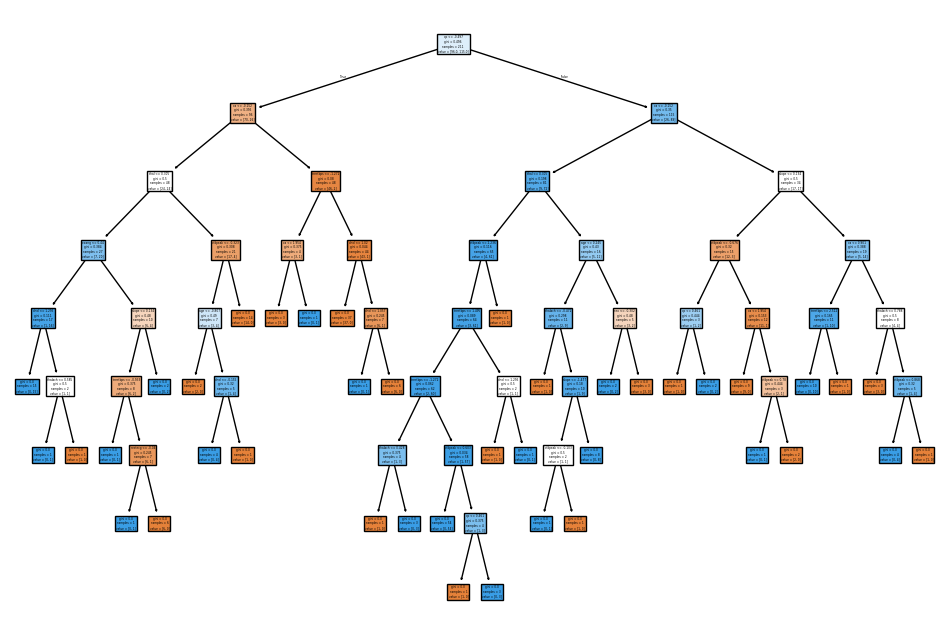

In [49]:
from sklearn.tree import plot_tree


plt.figure(figsize=(12,8))
plot_tree(DTmodel, feature_names=x.columns, filled=True)
plt.show()

### 5. Random Forest:
### a. Build a Random Forest model:
### i. Divide the dataset in 70:30 ratio
### ii. Build the model on train set and predict the values on test set
### iii. Build the confusion matrix and calculate the accuracy
### iv. Visualize the model using the Graphviz package

In [50]:
from sklearn.ensemble import RandomForestClassifier
RFmodel1=RandomForestClassifier(n_estimators =100)
RFmodel1.fit(x_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
y_pred=RFmodel1.predict(x_test_scaled)
y_pred

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1], dtype=int64)

In [52]:
accuracy_score_RF1=accuracy_score(y_test, y_pred)
accuracy_score_RF1

0.8351648351648352

In [53]:
confusion_matrix_RF1= confusion_matrix(y_test, y_pred)
confusion_matrix_RF1

array([[35,  7],
       [ 8, 41]], dtype=int64)

In [54]:
### Use different values of n_estimators

n=[50, 100, 200, 300, 400, 500]

accuracy=[]
for i in n:
    model=RandomForestClassifier(n_estimators=i)
    model.fit(x_train_scaled, y_train)
    predict1=model.predict(x_test_scaled)
    a=accuracy_score(y_test, predict1)*100
    accuracy.append(a)

accuracy


[81.31868131868131,
 83.51648351648352,
 84.61538461538461,
 84.61538461538461,
 85.71428571428571,
 85.71428571428571]

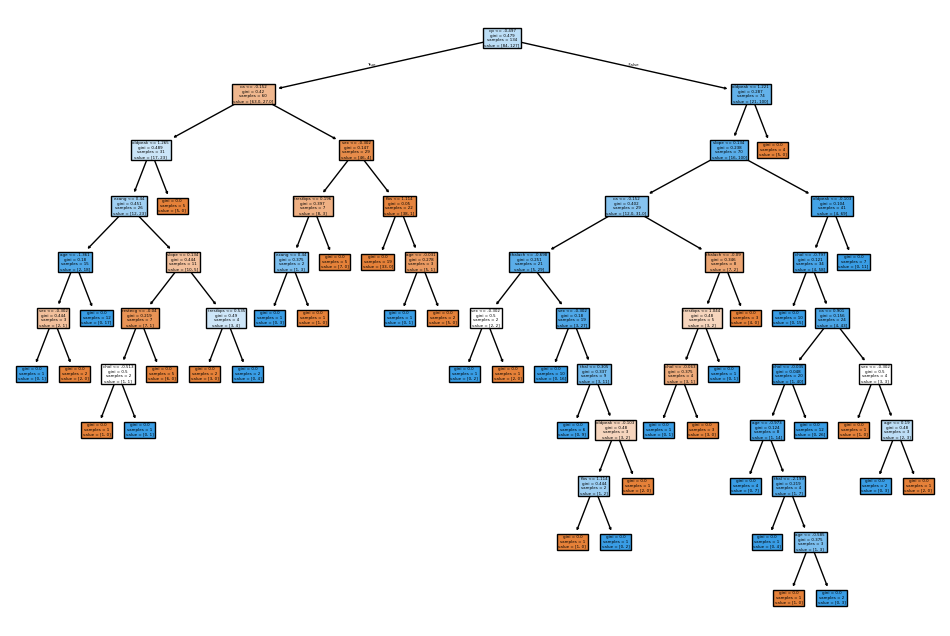

In [58]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(RFmodel1.estimators_[50], feature_names=x.columns, filled=True)
plt.show()

### Select the best model based on the best accuracies

#### In this project, the Random Forest model achieved the highest accuracy compared to other models. This is likely because Random Forest, as an ensemble method, combines multiple decision trees and reduces overfitting, leading to better generalization on the dataset. It is particularly effective in handling complex feature interactions and noise in the data.